In [1]:
from scripts.s1_rvl import compute_rvl, compute_rvl_gamma
import numpy as np
from matplotlib import pyplot as plt
import os
import xarray as xr

%matplotlib widget

In [2]:
slc_paths = []
slc_par_paths = []

for file in os.listdir('data/S1_data/test2'):
    if file[-4:] == '.slc':
        slc_paths.append(os.path.join('data/S1_data/test2', file))
    elif file[-4:] == '.par':
        slc_par_paths.append(os.path.join('data/S1_data/test2', file))
    else:
        continue

In [3]:
gamma_rvl = compute_rvl_gamma(slc_paths, slc_par_paths, 'data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE/annotation/s1a-iw1-slc-vv-20260205t165251-20260205t165319-063086-07eaef-004.xml', stride_az=32, stride_rg=64)

In [4]:
rvl = compute_rvl('data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE', 'iw1', stride_az=32, stride_rg=64)

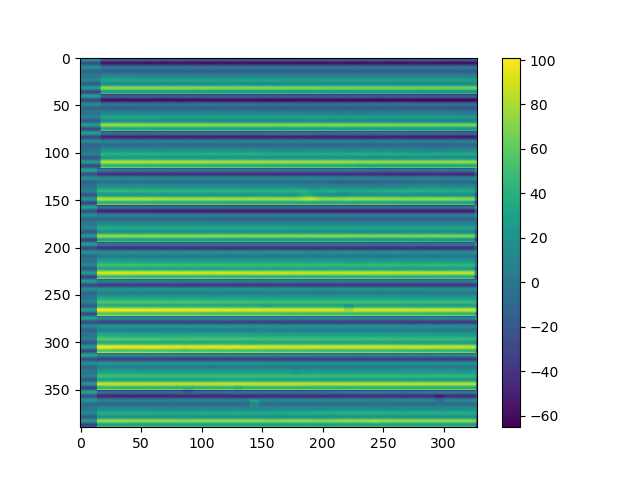

In [14]:
plt.close()
plt.imshow(rvl['doppler_hz'].values, aspect='auto')
plt.colorbar()
plt.show()

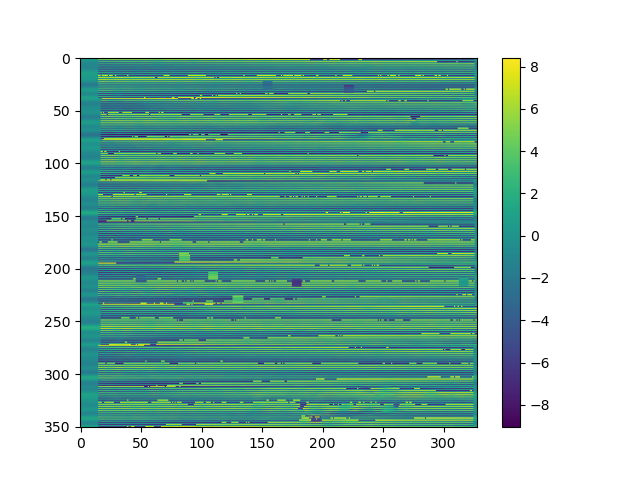

In [13]:
plt.close()
plt.imshow(gamma_rvl['radial_vel'].values, aspect='auto')
plt.colorbar()
plt.show()

In [2]:
ocn_prod = xr.open_dataset('data/S1_data/test2/S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE/measurement/s1a-iw-ocn-vv-20260205t165251-20260205t165322-063086-07EAEF-001.nc')

In [3]:
dc_obs = ocn_prod['rvlDcObs']
dc_geo = ocn_prod['rvlDcGeo']
dc_miss = ocn_prod['rvlDcMiss']

dc_corr = dc_obs-dc_geo-dc_miss

In [4]:
ocn_prod

<xarray.Dataset> Size: 33MB
Dimensions:                   (oswAzSize: 1, oswRaSize: 1,
                               oswAngularBinSize: 1, oswWavenumberBinSize: 1,
                               oswPartitions: 1, oswKyBinSize: 1,
                               oswKxBinSize: 1, oswLag: 1, owiAzSize: 195,
                               owiRaSize: 258, owiSwath: 3, owiPolarisation: 2,
                               owiIncSize: 156, rvlAzSize: 233, rvlRaSize: 128,
                               rvlSwath: 3, length: 26)
Coordinates:
    oswPartitions             (oswAzSize, oswRaSize, oswAngularBinSize, oswWavenumberBinSize) float32 4B ...
  * owiSwath                  (owiSwath) int8 3B 5 6 7
Dimensions without coordinates: oswAzSize, oswRaSize, oswAngularBinSize,
                                oswWavenumberBinSize, oswKyBinSize,
                                oswKxBinSize, oswLag, owiAzSize, owiRaSize,
                                owiPolarisation, owiIncSize, rvlAzSize,
                                rvlRaSize, rvlSwath, length
Data variables: (12/112)
    oswPolSpec                (oswAzSize, oswRaSize, oswAngularBinSize, oswWavenumberBinSize) float32 4B ...
    oswPolSpecNV              (oswAzSize, oswRaSize, oswAngularBinSize, oswWavenumberBinSize) float32 4B ...
    oswQualityCrossSpectraRe  (oswAzSize, oswRaSize, oswAngularBinSize, oswWavenumberBinSize) float32 4B ...
    oswQualityCrossSpectraIm  (oswAzSize, oswRaSize, oswAngularBinSize, oswWavenumberBinSize) float32 4B ...
    oswK                      (oswWavenumberBinSize) float32 4B ...
    oswPhi                    (oswAngularBinSize) float32 4B ...
    ...                        ...
    rvlSlantRangeTime         (rvlAzSize, rvlRaSize, rvlSwath) float32 358kB ...
    rvlZeroDopplerTime        (rvlAzSize, rvlRaSize, length, rvlSwath) object 19MB ...
    rvlGroundRngSize          (rvlAzSize, rvlRaSize, rvlSwath) float32 358kB ...
    rvlAziSize                (rvlAzSize, rvlRaSize, rvlSwath) float32 358kB ...
    rvlMask                   (rvlAzSize, rvlRaSize, rvlSwath) int8 89kB ...
    rvlSwathNumber            (rvlSwath) int8 3B ...
Attributes: (12/36)
    title:                   Sentinel-1 OCN Product
    oswAlgorithmVersion:     S-1 OSW rev 1/9
    statevectorUtc:          05-FEB-2026 16:53:02.692250
    statevectorPos:          [ 5296127.902583  2242908.961856 -4130120.103736]
    statevectorVel:          [4638.397598   82.157417 5999.503506]
    statevectorAcc:          [0. 0. 0.]
    ...                      ...
    owiNoiseCorrection:      True
    rfiMitigationActivated:  False
    prf:                     486.48631029955294
    iceSource:               EUMETSAT OSI SAF
    stokesSource:            WAVEWATCH III (R)
    windSource:              ECMWF

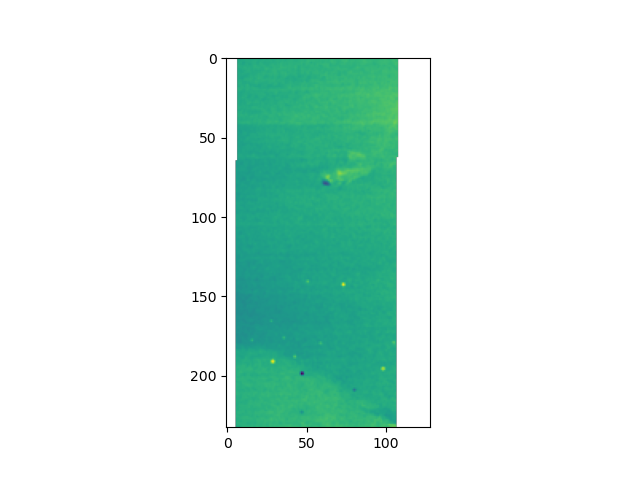

In [6]:
plt.imshow(ocn_prod['rvlRadVel'].values[...,0])
plt.show()

In [10]:
from scripts import s1_ocn
import matplotlib.pyplot as plt

In [11]:
SAFE_PATH = 'data/S1_data/test2/S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE'

pro = s1_ocn.retrieve_radial_current(SAFE_PATH, polarisation='vv', swath_index=0)

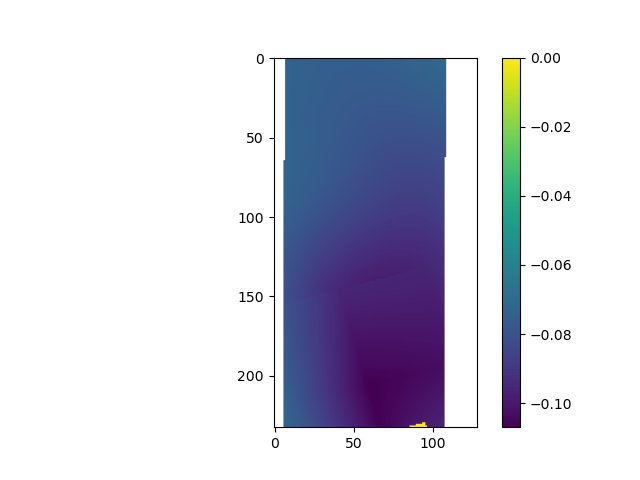

In [13]:
plt.close()
plt.imshow(ocn_prod['rvlRadVel'].values[...,0] - pro['currentRadVel'].values)
plt.colorbar()

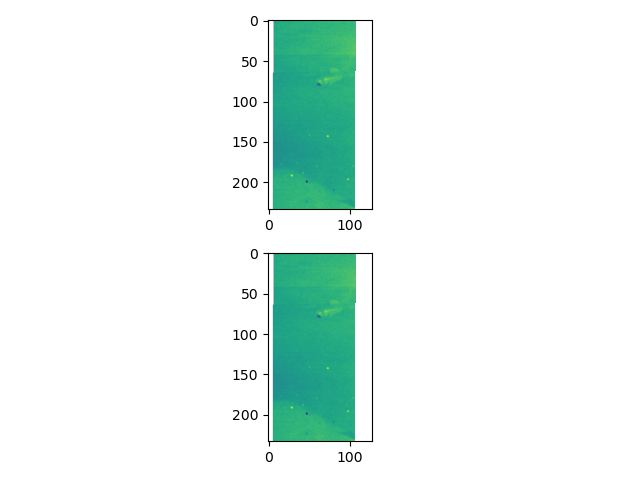

In [14]:
plt.close()
fig,ax = plt.subplots(2,1)

ax[0].imshow(ocn_prod['rvlRadVel'].values[...,0])

ax[1].imshow(pro['currentRadVel'].values)

plt.tight_layout()
plt.show()